# SAAM Project - Complete Notebook

This notebook combines Part I and Part II.


# SAAM Project 2026
---
## Part I : Standard Portfolio Allocation
### Group N : Emerging Markets / Scope 1
---

## 1. Project Overview

This notebook implements Part I of the SAAM project for Group N, which focuses on firms from Emerging Markets and uses Scope 1 emissions as the climate metric for the broader project.  

The objective of Part I is to construct and compare two portfolio strategies over the out-of-sample period 2014–2025:

- a long-only minimum variance portfolio,
- a value-weighted benchmark portfolio.

The notebook follows the project instructions by:
- cleaning and preparing the financial data,
- constructing monthly stock returns,
- defining a dynamic investment universe,
- estimating portfolio weights annually using a rolling 120-month window,
- backtesting the portfolios on a monthly basis,
- and comparing their performance using standard portfolio statistics.

---
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section sert à expliquer dès le début ce que couvre ce notebook.
Pour l’instant, ce notebook couvre uniquement la Part I :
- minimum variance portfolio
- value-weighted benchmark
- comparaison des performances

Quand vous reprendrez le notebook pour la Part II, il faudra prolonger la logique ici, mais sans réécrire toute l’introduction.

---


## 2. Environment Setup and Project Configuration
This section prepares the computational environment used throughout the notebook.

It loads the required Python libraries, defines the project folder structure,
and sets the global parameters used in the portfolio construction process.

Organizing these elements at the beginning of the notebook ensures that the
analysis remains reproducible and easy to maintain.

----
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section doit rester stable.
Elle contient :
- les librairies
- les chemins du projet
- les paramètres globaux

Si quelqu’un modifie les noms de dossiers, les fichiers de données ou les hypothèses générales, cela doit être fait ici en priorité.

---

### 2.1 Importing required libraries

The following libraries are required to run the analysis.

Pandas and NumPy are used for data manipulation, Matplotlib is used for
visualization, and SciPy provides the optimization routines used to
construct the minimum variance portfolio.

In [1]:
from pathlib import Path
import os
import sys

# Detect project root automatically
BASE_DIR = Path.cwd().resolve()

while not (BASE_DIR / "data_raw").exists():
    if BASE_DIR.parent == BASE_DIR:
        raise FileNotFoundError("Could not find project root containing data_raw/")
    BASE_DIR = BASE_DIR.parent

os.chdir(BASE_DIR)

# Main folders
DATA_RAW = BASE_DIR / "data_raw"
DATA_PROCESSED = BASE_DIR / "data_processed"
OUTPUTS = BASE_DIR / "outputs"

# Output subfolders
TABLES_DIR = OUTPUTS / "tables"
FIGURES_DIR = OUTPUTS / "figures"
INTERMEDIATE_DIR = OUTPUTS / "intermediate"

# Make common src/ folder importable
SRC_DIR = BASE_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Create folders if needed
DATA_PROCESSED.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERMEDIATE_DIR.mkdir(exist_ok=True)

# Quiet checks: no local path printed in the notebook output
assert DATA_RAW.exists(), "data_raw folder not found"
assert SRC_DIR.exists(), "src folder not found"
assert OUTPUTS.exists(), "outputs folder not found"

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

### 2.2 Verifying the Python environment

Before running the rest of the analysis, we verify that the required
libraries are correctly installed and accessible.

In [3]:
# Display library versions to ensure reproducibility of the computational environment

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Imports loaded successfully.")

Pandas version: 3.0.3
NumPy version: 2.4.5
Imports loaded successfully.


### 2.3 Display configuration

The following settings improve the readability of data tables displayed
in the notebook by controlling the number of rows, columns, and numerical formatting.

In [4]:
# Configure pandas display settings to improve readability of DataFrame outputs

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.4f}".format)

### 2.4 Defining project directories

To keep the workflow organized and reproducible, the main project
directories are defined here. All file paths used later in the notebook
are constructed relative to the project base directory.

In [5]:
from pathlib import Path
import os

# Chemin exact du projet
BASE_DIR = Path("/Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project")

# Forcer Jupyter à revenir dans le bon dossier
os.chdir(BASE_DIR)

# Main folders
DATA_RAW = BASE_DIR / "data_raw"
DATA_PROCESSED = BASE_DIR / "data_processed"
OUTPUTS = BASE_DIR / "outputs"

# Output subfolders
TABLES_DIR = OUTPUTS / "tables"
FIGURES_DIR = OUTPUTS / "figures"
INTERMEDIATE_DIR = OUTPUTS / "intermediate"

# Créer les dossiers si besoin
DATA_PROCESSED.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERMEDIATE_DIR.mkdir(exist_ok=True)

print("Project root detected at:", BASE_DIR)
print("Current working directory:", Path(os.getcwd()))
print("DATA_RAW exists:", DATA_RAW.exists())
print("OUTPUTS exists:", OUTPUTS.exists())


Project root detected at: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project
Current working directory: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project
DATA_RAW exists: True
OUTPUTS exists: True


In [6]:
# Verify that the project directories are correctly defined

print("Current working directory:", Path.cwd())
print("BASE_DIR:", BASE_DIR)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("OUTPUTS:", OUTPUTS)

Current working directory: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project
BASE_DIR: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project
DATA_RAW: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/data_raw
DATA_PROCESSED: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/data_processed
OUTPUTS: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/outputs


### 2.5 Creating required folders

The following step ensures that all output directories exist before
running the analysis. If a folder does not exist, it is automatically created.

In [7]:
# Ensure that all required output directories exist.
# If a folder does not exist, it is created automatically.

for folder in [DATA_PROCESSED, OUTPUTS, TABLES_DIR, FIGURES_DIR, INTERMEDIATE_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Output directories checked and created if necessary.")

Output directories checked and created if necessary.


### 2.6 Global project parameters

This block defines the main parameters used throughout the project,
including the estimation window, filtering rules, and portfolio assumptions.
Centralizing these parameters simplifies future modifications.

In [8]:
# Global project parameters
REGION = "EM"
CARBON_SCOPE = "SCOPE_1"

# Project timeline
START_ESTIMATION_YEAR = 2013
END_REBALANCE_YEAR = 2024
BACKTEST_START_YEAR = 2014
BACKTEST_END_YEAR = 2025

# Estimation and filtering rules
ROLLING_WINDOW_MONTHS = 120
MIN_HISTORY_MONTHS = 36
STALE_RETURN_THRESHOLD = 0.50
LOW_PRICE_THRESHOLD = 0.5

# Portfolio assumptions
INITIAL_WEALTH = 1_000_000
CARBON_REDUCTION_TARGET = 0.50
NET_ZERO_REDUCTION = 0.10

In [9]:
# Display the main project parameters used throughout the notebook

print("Assigned region:", REGION)
print("Carbon scope:", CARBON_SCOPE)
print("Estimation window (months):", ROLLING_WINDOW_MONTHS)
print("Initial portfolio wealth (USD):", INITIAL_WEALTH)

Assigned region: EM
Carbon scope: SCOPE_1
Estimation window (months): 120
Initial portfolio wealth (USD): 1000000


## 3. Data Loading
This section loads the raw datasets used in Part I of the project.

At this stage, the objective is only to import the original files and
perform a minimal structural inspection. No financial cleaning or portfolio
construction is performed yet.

---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section sert uniquement à charger les fichiers bruts et à vérifier leur structure.
On ne fait pas encore ici :
- le filtrage Emerging Markets
- le nettoyage des prix
- le calcul des rendements
- la création de l’univers dynamique

Tout cela ira dans la section 4.

----

### 3.1 Loading the raw datasets

The following datasets are loaded from the project folder.
For Part I, the key files are the static firm information, monthly return index data,
and monthly market capitalization data.

Annual carbon emissions are also loaded at this stage, even though the carbon objective is introduced in Part II. This is necessary because the project instructions require the investment universe in Part I to exclude firms without carbon data available at the end of each year.

In [10]:
# Load the main datasets used in Part I:
# - Static firm information (region, identifiers, characteristics)
# - Monthly total return index prices
# - Monthly market capitalizations
# - Annual carbon emissions for the assigned scope

static = pd.read_excel(DATA_RAW / "Static_2025.xlsx")
prices_raw = pd.read_excel(DATA_RAW / "DS_RI_T_USD_M_2025.xlsx")
market_caps_raw = pd.read_excel(DATA_RAW / "DS_MV_T_USD_M_2025.xlsx")
carbon_raw = pd.read_excel(DATA_RAW / "DS_CO2_SCOPE_1_Y_2025.xlsx")

### 3.2 Inspecting the raw dataset structure

Before cleaning the data, we verify that the files have been loaded correctly
and contain the expected dimensions and key identifier columns.

In [11]:
# Inspect dataset dimensions to verify that the files were loaded correctly

print("Static shape:", static.shape)
print("Prices raw shape:", prices_raw.shape)
print("Market caps raw shape:", market_caps_raw.shape)
print("Carbon raw shape:", carbon_raw.shape)

Static shape: (2545, 4)
Prices raw shape: (2609, 316)
Market caps raw shape: (2609, 316)
Carbon raw shape: (2609, 29)


In [12]:
# Inspect the structure of the static dataset (firm characteristics)

static.head()

,ISIN,NAME,Country,Region
0,AN8068571086,SLB,US,AMER
1,ARALUA010258,ALUAR,AR,EM
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM
4,AT000000STR1,STRABAG SE,AT,EUR


In [13]:
# Inspect the raw monthly price dataset to verify its structure,
# including identifier columns and potential Datastream extraction issues

prices_raw.head()

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
0,NaN,NaN,"$$ER: E100,INVALID CODE OR EXPRESSION ENTERED",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SLB,AN8068571086,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
2,ALUAR,ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
3,BANCO BBVA ARGENTINA,ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600


In [14]:
# Inspect the raw market capitalization dataset to verify its structure
# and ensure consistency with the price dataset

market_caps_raw.head()

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
0,NaN,NaN,"$$ER: E100,INVALID CODE OR EXPRESSION ENTERED",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SLB,AN8068571086,30859.9900,33574.8500,40611.1300,43352.4300,43387.8600,41861.3900,42466.0200,42074.7900,48547.8000,46840.6300,43319.5800,35281.6500,45489.1100,43703.7000,36277.5000,33017.7200,38261.7900,36374.6700,30384.3600,31019.1700,28277.9500,26373.5100,27943.2300,...,69774.5000,69244.3800,78342.0000,67864.9400,65592.3100,67436.1300,68571.8100,62465.8400,59239.8300,56585.0100,62050.0500,53708.5900,54774.9500,56651.5700,56854.7300,45225.3700,44953.3100,45672.2000,50485.0000,55025.6200,51346.1400,53870.8800,54139.7800,57390.8200,72344.1300
2,ALUAR,ARALUA010258,1129.3100,1328.6400,1395.0700,1362.2300,1340.1900,1317.7800,1209.8900,1395.6900,1447.5500,1361.7300,1296.3200,1188.2900,1038.5400,1209.9300,1209.7300,1123.7900,1123.6700,1144.8800,1070.6100,1070.9100,1045.1200,917.7600,943.4500,...,3487.1000,2599.4200,2915.9000,2698.6000,3165.1600,3033.3400,2875.1800,2694.7000,2494.6300,2381.9600,2635.6000,2425.2200,2291.7000,2025.1000,2301.3300,1563.0200,1869.8000,1688.6600,1644.1600,1534.0000,1410.7100,1909.8600,2030.7600,1919.3200,2034.6000
3,BANCO BBVA ARGENTINA,ARP125991090,1656.3000,1570.3900,1851.3400,1656.8200,1388.7000,1352.2200,1541.0500,1551.5400,1528.4800,1457.8300,1515.9000,1352.3600,1450.8900,2170.1400,2020.9200,1809.9500,1887.3500,1890.8800,1740.0100,1023.3300,960.1500,620.5900,601.8500,...,1913.2300,1658.4500,2192.6300,2435.1100,3210.5400,2818.3400,2409.4900,2832.3400,2697.8500,3274.7300,3745.7400,4516.5800,5131.4500,4362.1900,4527.7200,4201.9100,4030.1500,3396.7200,3264.1100,2550.0400,1892.8100,3503.8900,3470.1500,3896.0400,4308.3300
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,1414.3700,1407.4700,1463.0800,1460.0100,1356.0400,893.0500,955.7000,990.4500,1087.7600,1022.1800,920.9500,816.7000,859.6300,1108.6500,854.8000,879.5000,799.4600,785.2800,639.3700,510.9400,462.1500,389.2200,271.1200,...,5609.1600,4056.7700,4698.8000,4340.6300,5146.5600,4829.1500,4589.9200,3971.8900,3870.7500,3641.8900,4278.7300,3903.7100,3645.5000,3075.5600,3443.2200,2335.9000,2635.1600,2337.2300,2345.7400,1948.3300,1892.4100,2260.0900,2506.9200,2095.8700,2196.5400


### 3.3 Checking identifier columns

The Datastream files contain both identifier columns and time-series columns.
At this stage, we verify that ISIN is available and that the first columns
match the expected raw file structure.

In [15]:
# Inspect column names to verify dataset structure
# This helps identify identifier columns and date columns in the raw datasets

print("Static columns:", static.columns.tolist())
print("Prices raw first columns:", prices_raw.columns[:10].tolist())
print("Market caps raw first columns:", market_caps_raw.columns[:10].tolist())

Static columns: ['ISIN', 'NAME', 'Country', 'Region']
Prices raw first columns: ['NAME', 'ISIN', datetime.datetime(1999, 12, 31, 0, 0), datetime.datetime(2000, 1, 31, 0, 0), datetime.datetime(2000, 2, 29, 0, 0), datetime.datetime(2000, 3, 31, 0, 0), datetime.datetime(2000, 4, 28, 0, 0), datetime.datetime(2000, 5, 31, 0, 0), datetime.datetime(2000, 6, 30, 0, 0), datetime.datetime(2000, 7, 31, 0, 0)]
Market caps raw first columns: ['NAME', 'ISIN', datetime.datetime(1999, 12, 31, 0, 0), datetime.datetime(2000, 1, 31, 0, 0), datetime.datetime(2000, 2, 29, 0, 0), datetime.datetime(2000, 3, 31, 0, 0), datetime.datetime(2000, 4, 28, 0, 0), datetime.datetime(2000, 5, 31, 0, 0), datetime.datetime(2000, 6, 30, 0, 0), datetime.datetime(2000, 7, 31, 0, 0)]


In [16]:
# Verify that the identifier column (ISIN) is present in the raw datasets

print("ISIN column in prices dataset:", "ISIN" in prices_raw.columns)
print("ISIN column in market caps dataset:", "ISIN" in market_caps_raw.columns)

ISIN column in prices dataset: True
ISIN column in market caps dataset: True


### 3.4 Setting ISIN as the raw index

To facilitate later filtering and alignment across datasets, the ISIN code
is used as the row index for the raw price and market capitalization tables.
At this stage, non-time-series columns are still kept unchanged.

In [17]:
# Set ISIN as the index to structure datasets as asset-by-time matrices

prices_raw = prices_raw.set_index("ISIN")
market_caps_raw = market_caps_raw.set_index("ISIN")

In [18]:
# Confirm that ISIN has been correctly set as the index for both datasets

print("Prices raw index name:", prices_raw.index.name)
print("Market caps raw index name:", market_caps_raw.index.name)

Prices raw index name: ISIN
Market caps raw index name: ISIN


In [19]:
# Inspect the dataset after setting ISIN as the index
# This confirms the new row structure and helps identify remaining non-time-series columns

prices_raw.head()

,NAME,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,2001-11-30 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,"$$ER: E100,INVALID CODE OR EXPRESSION ENTERED",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AN8068571086,SLB,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,1490.3100,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
ARALUA010258,ALUAR,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,1324.8400,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
ARP125991090,BANCO BBVA ARGENTINA,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,145.1300,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,33.0100,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600


## 4. Data Cleaning and Preparation

This section prepares the raw datasets for the empirical analysis.

The main objective is to isolate the firms belonging to the relevant investment region,
remove non-usable raw content from the Datastream files, and construct clean
time-series tables for prices and market capitalizations.

---
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section sert à transformer les fichiers bruts en tables exploitables.

À ce stade, on va seulement :
- garder les entreprises EM
- retirer les lignes parasites Datastream
- enlever la colonne NAME
- convertir les colonnes de dates
- préparer les tables finales prices / market caps

On ne calcule pas encore les rendements ici.

----

### 4.1 Filtering the Emerging Markets universe


The project is conducted for Group N, which is assigned to the Emerging Markets region.

The first cleaning step therefore consists in restricting the firm universe
to companies classified as Emerging Markets in the static reference table.

---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on construit l’univers régional de départ.
Pour notre groupe, on garde uniquement les entreprises avec `Region = EM`.

Attention :
ce n’est pas encore l’univers investissable final.
C’est seulement le filtrage régional brut.
L’univers dynamique viendra plus tard.

---

In [20]:
# Define the investment universe by selecting firms belonging to the assigned region

em_firms = static[static["Region"] == REGION].copy()
em_isins = em_firms["ISIN"].tolist()

print("Number of firms in the Emerging Markets universe:", len(em_isins))

Number of firms in the Emerging Markets universe: 702


In [21]:
# Inspect the selected regional universe after filtering the static dataset

em_firms.head()

,ISIN,NAME,Country,Region
1,ARALUA010258,ALUAR,AR,EM
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM
117,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM
144,BRABEVACNOR1,AMBEV ON,BR,EM


In [22]:
# Prepare carbon emissions dataset

# If ISIN is still a column, use it as index
if "ISIN" in carbon_raw.columns:
    carbon_raw = carbon_raw.set_index("ISIN")

# Remove rows without valid identifiers
carbon_raw = carbon_raw[carbon_raw.index.notna()]

# Remove the non-time-series column (NAME) if still present
if "NAME" in carbon_raw.columns:
    carbon_clean = carbon_raw.drop(columns="NAME").copy()
else:
    carbon_clean = carbon_raw.copy()

# Keep only firms belonging to the EM universe
carbon_data = carbon_clean.loc[carbon_clean.index.isin(em_isins)].copy()

# Convert carbon values to numeric and coerce Datastream error strings to NaN
carbon_data = carbon_data.apply(pd.to_numeric, errors="coerce")

# Fill missing annual values forward as suggested in the project instructions
carbon_data = carbon_data.ffill(axis=1)

# Convert annual columns to end-of-year datetime
carbon_data.columns = pd.to_datetime(carbon_data.columns.astype(str), format="%Y")
carbon_data.columns = carbon_data.columns + pd.offsets.YearEnd(0)

# Ensure chronological order
carbon_data = carbon_data.sort_index(axis=1)

print("Carbon dataset shape:", carbon_data.shape)
carbon_data.head()

Carbon dataset shape: (702, 27)


,1999-12-31,2000-12-31,2001-12-31,2002-12-31,2003-12-31,2004-12-31,2005-12-31,2006-12-31,2007-12-31,2008-12-31,2009-12-31,2010-12-31,2011-12-31,2012-12-31,2013-12-31,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31,2025-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARALUA010258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2414112.0000,2414112.0000
ARP125991090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9969.6700,8198.6700,7038.6500,7038.6500,7038.6500,442.6200,366.8600,1091.1300,1475.2000,1475.2000
ARSIDE010029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMG211591018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38468.0000,51886.0000,51515.0000,76154.0000,21477.0000,21301.0000,14980.0000,13173.0000,13173.0000
BRABEVACNOR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,356414.0000,351297.0000,274598.0000,457821.0000,668740.0000,581763.0000,576069.0900,484000.0000,483000.0000,483000.0000


### 4.2 Removing invalid raw rows

Some Datastream exports may contain invalid rows generated during the data extraction process.

These rows typically appear with missing identifiers or error messages
in the first observation row. Such entries do not correspond to real firms
and must therefore be removed before proceeding with the data preparation.

---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Dans les fichiers Datastream, il arrive qu'une ligne d'erreur apparaisse
en haut du fichier (ex: "INVALID CODE OR EXPRESSION ENTERED").

Cette ligne n'est pas une entreprise et doit être supprimée.
On supprime simplement les lignes dont l'ISIN est manquant.

---

In [23]:
# Remove rows with missing ISIN identifiers
# These rows may appear in Datastream exports due to extraction errors

prices_raw = prices_raw[prices_raw.index.notna()]
market_caps_raw = market_caps_raw[market_caps_raw.index.notna()]

In [24]:
# Check dataset dimensions after removing rows with missing ISIN identifiers

print("Prices raw shape after cleaning:", prices_raw.shape)
print("Market caps raw shape after cleaning:", market_caps_raw.shape)

Prices raw shape after cleaning: (2545, 315)
Market caps raw shape after cleaning: (2545, 315)


In [25]:
# Inspect the price dataset after removing invalid rows

prices_raw.head()

,NAME,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,2001-11-30 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AN8068571086,SLB,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,1490.3100,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
ARALUA010258,ALUAR,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,1324.8400,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
ARP125991090,BANCO BBVA ARGENTINA,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,145.1300,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,33.0100,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,176.2400,176.5900,195.7400,198.0000,204.5600,204.4100,205.0600,212.4700,204.9400,192.7100,199.6300,200.2800,240.2600,286.2000,349.6200,430.2700,430.8300,479.4600,477.3500,465.0600,461.5000,396.6500,452.8700,481.4900,526.8800


### 4.3 Removing non-time-series columns

The Datastream price and market capitalization files contain descriptive columns
in addition to the monthly time-series data.

Since the portfolio construction relies exclusively on time-series information,
these descriptive columns must be removed to obtain clean numerical matrices.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Les fichiers Datastream contiennent encore la colonne `NAME`.
Elle sert uniquement à identifier visuellement les entreprises.

Pour les calculs financiers (rendements, covariance, optimisation),
on ne doit garder que les colonnes de dates.

Attention :
ISIN est déjà dans l'index, donc on ne supprime qu'une seule colonne ici.

---



In [26]:
# Remove the non-time-series column (NAME) and keep only date columns
# This converts the dataset into an asset-by-time matrix

prices_clean = prices_raw.iloc[:, 1:].copy()
market_caps_clean = market_caps_raw.iloc[:, 1:].copy()

In [27]:
# Check dataset dimensions after removing non-time-series columns

print("Prices clean shape:", prices_clean.shape)
print("Market caps clean shape:", market_caps_clean.shape)

Prices clean shape: (2545, 314)
Market caps clean shape: (2545, 314)


In [28]:
# Inspect the cleaned price matrix after removing non-time-series columns

prices_clean.head()

,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,2001-11-30 00:00:00,2001-12-31 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AN8068571086,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,1490.3100,1711.8600,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,1324.8400,1429.9700,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,145.1300,167.4900,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,33.0100,48.1300,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600
AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,176.2400,176.5900,195.7400,198.0000,204.5600,204.4100,205.0600,212.4700,204.9400,192.7100,199.6300,200.2800,240.2600,286.2000,349.6200,430.2700,430.8300,479.4600,477.3500,465.0600,461.5000,396.6500,452.8700,481.4900,526.8800


### 4.4 Converting time-series columns to datetime

To ensure proper time-series handling, the column labels representing
monthly observations are explicitly converted to datetime objects.

This allows chronological sorting and facilitates the later
construction of return series and portfolio backtests.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Même si les colonnes ressemblent déjà à des dates,
on force la conversion en datetime pour éviter tout problème
dans les manipulations temporelles.

C'est une bonne pratique standard en analyse financière.

---



In [29]:
# Convert column labels to datetime format for time-series operations

prices_clean.columns = pd.to_datetime(prices_clean.columns)
market_caps_clean.columns = pd.to_datetime(market_caps_clean.columns)

In [30]:
# Ensure columns (dates) are ordered chronologically

prices_clean = prices_clean.sort_index(axis=1)
market_caps_clean = market_caps_clean.sort_index(axis=1)

In [31]:
# Verify that the columns are now a datetime index and inspect the first dates

print("Column index type:", type(prices_clean.columns))
print("First dates in price dataset:", prices_clean.columns[:5])

Column index type: <class 'pandas.DatetimeIndex'>
First dates in price dataset: DatetimeIndex(['1999-12-31', '2000-01-31', '2000-02-29', '2000-03-31',
               '2000-04-28'],
              dtype='datetime64[us]', freq=None)


### 4.5 Preparing the final clean matrices

After cleaning the raw Datastream exports, the final step consists in
restricting the datasets to the relevant investment universe.

Only firms belonging to the Emerging Markets region are retained.
The resulting price and market capitalization matrices will serve
as the basis for the subsequent return calculations and portfolio construction.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on applique réellement le filtre régional.

Jusqu'ici les matrices contiennent toutes les entreprises.
On garde uniquement celles présentes dans `em_isins`.

Les matrices finales utilisées dans tout le projet seront :

price_data
market_caps_data

---



In [32]:
# Restrict datasets to the Emerging Markets investment universe

price_data = prices_clean.loc[prices_clean.index.isin(em_isins)].copy()
market_caps_data = market_caps_clean.loc[market_caps_clean.index.isin(em_isins)].copy()

In [33]:
# Verify the dimensions of the EM investment universe matrices

print("Price matrix shape:", price_data.shape)
print("Market cap matrix shape:", market_caps_data.shape)

Price matrix shape: (702, 314)
Market cap matrix shape: (702, 314)


In [34]:
# Inspect the final monthly price matrix for the Emerging Markets investment universe

price_data.head()

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,2000-10-31,2000-11-30,2000-12-29,2001-01-31,2001-02-28,2001-03-30,2001-04-30,2001-05-31,2001-06-29,2001-07-31,2001-08-31,2001-09-28,2001-10-31,2001-11-30,2001-12-31,...,2024-01-31,2024-02-29,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,1324.8400,1429.9700,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,145.1300,167.4900,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,33.0100,48.1300,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600
BMG211591018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.6700,0.6600,0.6300,0.5900,0.5900,0.5600,0.5100,0.5900,0.6200,0.8000,0.6700,0.6300,0.5600,0.5600,0.5600,0.6000,0.5200,0.5200,0.6000,0.5700,0.5400,0.5000,0.4900,0.4000,0.4600
BRABEVACNOR1,61.8000,59.0700,56.3800,74.0800,73.9800,70.8200,89.5800,110.7400,110.0500,119.7800,141.0300,140.0800,172.5400,188.5200,171.6500,161.8700,170.5200,154.6600,159.9400,144.5000,127.9900,97.1600,104.5600,115.3600,133.5200,...,1272.8500,1217.4000,1199.7800,1127.1400,1057.5700,987.7300,985.0100,1091.8500,1154.8900,1049.9200,1025.1800,963.6200,963.5500,1055.8900,1206.4100,1317.2700,1263.9500,1260.2800,1149.2800,1187.0900,1184.4800,1231.4500,1353.4100,1392.2400,1561.2700


## 5. Construction of Monthly Returns

### 5.1 Filtering unrealistic prices

Datastream price series may contain observations corresponding to extremely
low prices, which often reflect illiquid securities, penny stocks,
or data extraction issues.

To mitigate the impact of such observations on the return calculations,
prices below 0.5 USD are treated as missing values.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On applique ici la règle utilisée dans l'ancien notebook.

Les prix < 0.5 sont considérés comme non fiables :
- penny stocks
- erreurs Datastream
- problèmes de liquidité

On remplace ces valeurs par NaN avant de calculer les rendements.

---



In [35]:
# Ensure all price observations are numeric
price_data = price_data.apply(pd.to_numeric, errors="coerce")

# Identify abnormal price observations (Datastream convention: prices < 0.5)
(price_data < 0.5).sum().sum()

np.int64(21077)

In [36]:
# Replace abnormal Datastream price observations (< 0.5) with missing values

price_data[price_data < 0.5] = np.nan

In [37]:
# ensure chronological order of price observations
price_data = price_data.sort_index(axis=1)

### 5.2 Computing monthly returns

Monthly returns are computed from the Datastream return index series using simple percentage changes between consecutive monthly observations.

Special attention is paid to firms that disappear at the end of the sample. In line with the project instructions, if a firm has a last valid price observation followed only by missing values, the first missing month is interpreted as a delisting event and assigned a return of −100%.

---
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On garde ici la logique demandée par le projet :
- rendements simples mensuels
- pas de clipping
- si une firme disparaît définitivement en fin de série, on attribue un rendement de -100% au premier mois manquant après le dernier prix observé

---

----
Contenu à effacer mais important à voir en groupe:



In [38]:
# Compute simple monthly returns from price indices
# fill_method=None avoids implicit filling around missing values

returns = price_data.pct_change(axis=1, fill_method=None)

# Approximate delisting returns:
# if a firm has a last valid price and all following prices are missing,
# assign -100% to the first missing month after the last valid observation

for isin in price_data.index:
    prices = price_data.loc[isin]
    valid_mask = prices.notna()

    if valid_mask.any():
        last_valid_pos = np.where(valid_mask.values)[0][-1]

        if last_valid_pos < len(prices.index) - 1:
            trailing_block = prices.iloc[last_valid_pos + 1:]

            if trailing_block.isna().all():
                first_missing_date = prices.index[last_valid_pos + 1]
                returns.loc[isin, first_missing_date] = -1.0

In [39]:
# Diagnostic: inspect the most extreme monthly returns

stacked_returns = returns.stack()

print("Minimum return:", stacked_returns.min())
print("Maximum return:", stacked_returns.max())

print("\nFive most negative returns:")
print(stacked_returns.nsmallest(5))

print("\nFive most positive returns:")
print(stacked_returns.nlargest(5))

Minimum return: -1.0
Maximum return: 9.419463087248323

Five most negative returns:
ISIN                    
BMG211591018  2025-11-28   -1.0000
BRBRFSACNOR8  2025-09-30   -1.0000
BRCESPACNPB4  2022-03-31   -1.0000
BRCPLEACNPB9  2025-11-28   -1.0000
BRGFSAACNOR3  2022-04-29   -1.0000
dtype: float64

Five most positive returns:
ISIN                    
TW0003376000  2005-12-30   9.4195
EGS673T1C012  2007-07-31   7.1042
GRS314003013  2023-02-28   3.1153
CL0000000423  2022-09-30   2.9167
INE686F01025  2004-11-30   1.9846
dtype: float64


In [40]:
stacked_returns = returns.stack()
print("Returns exactly -100%:", (stacked_returns == -1).sum())

Returns exactly -100%: 62


In [41]:
# Count very large return observations

print("Returns < -100%:", (stacked_returns < -1).sum())
print("Returns exactly -100%:", (stacked_returns == -1).sum())
print("Returns > 100%:", (stacked_returns > 1).sum())
print("Returns > 200%:", (stacked_returns > 2).sum())
print("Returns > 500%:", (stacked_returns > 5).sum())

Returns < -100%: 0
Returns exactly -100%: 62
Returns > 100%: 67
Returns > 200%: 4
Returns > 500%: 2



The distribution of monthly returns was inspected to detect potential data anomalies. While a small number of extremely large positive returns were observed (above 200%), these observations correspond to firms with very small market capitalizations and therefore have negligible impact in the value-weighted benchmark. For consistency with the project instructions, returns were not winsorized.

----

In [42]:
# Inspect the first few monthly returns to verify the return calculation
returns.iloc[:, :5].head()

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28
ISIN,,,,,
ARALUA010258,NaN,0.1765,0.0500,-0.0236,-0.0162
ARP125991090,NaN,-0.0519,0.1789,-0.1051,-0.1618
ARSIDE010029,NaN,-0.0049,0.0395,-0.0021,-0.0712
BMG211591018,NaN,NaN,NaN,NaN,NaN
BRABEVACNOR1,NaN,-0.0442,-0.0455,0.3139,-0.0013


### 5.3 Inspecting the return distribution

At this stage, the return matrix is inspected to verify that the price cleaning procedure has removed the most problematic observations. In particular, treating prices below 0.5 as missing values helps prevent mechanically inflated returns caused by extremely low price levels.

---
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on ne winsorise pas les rendements.
On se contente d’inspecter leur distribution après le nettoyage des prix.

La logique du projet est surtout :
- traiter les prix < 0.5 comme manquants
- exclure certaines firmes de l’univers si nécessaire
- laisser apparaître les vrais rendements extrêmes, notamment en cas de delisting

---

In [43]:
# Summarize the distribution of cleaned monthly returns

returns.stack().describe()

count   185798.0000
mean         0.0138
std          0.1266
min         -1.0000
25%         -0.0518
50%          0.0069
75%          0.0709
max          9.4195
dtype: float64

### 5.4 Constructing the return matrix

The final return matrix is defined after cleaning the monthly return series and handling extreme observations.

This matrix constitutes the main input for the dynamic investment universe, covariance estimation, and portfolio backtesting procedures developed in the following sections.

In [44]:
# Create the final return matrix used for portfolio construction

returns_matrix = returns.copy()

In [45]:
# Check the dimensions of the final return matrix used for portfolio analysis
print("Return matrix shape:", returns_matrix.shape)

Return matrix shape: (702, 314)


In [46]:
# Inspect a small portion of the final return matrix

returns_matrix.iloc[:5, :5]

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28
ISIN,,,,,
ARALUA010258,NaN,0.1765,0.0500,-0.0236,-0.0162
ARP125991090,NaN,-0.0519,0.1789,-0.1051,-0.1618
ARSIDE010029,NaN,-0.0049,0.0395,-0.0021,-0.0712
BMG211591018,NaN,NaN,NaN,NaN,NaN
BRABEVACNOR1,NaN,-0.0442,-0.0455,0.3139,-0.0013


## 6. Dynamic Investment Universe

This section defines the dynamic investment universe used for portfolio construction.

Rather than assuming that all firms are investable at all times, the eligible universe is redefined each year based on data availability and basic screening rules. This ensures that the portfolio optimization is performed on firms with sufficiently informative return histories.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on construit l’univers investissable annuel.

Ce n’est plus seulement le filtre régional EM :
on applique maintenant les règles de disponibilité des données.

L’idée est simple :
à chaque année de rebalancement, on regarde les 120 mois précédents
et on garde seulement les firmes qui ont un historique exploitable.

---



### 6.1 Defining the rebalancing years

Portfolio weights are re-estimated annually. For each rebalancing year, the estimation window uses the previous 120 monthly observations.

In [47]:
# Define the years for annual portfolio rebalancing
rebalance_years = list(range(2014, 2026))

rebalance_years

[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

### 6.2 Defining firm eligibility rules

A firm is considered eligible if it has a sufficiently long return history and does not exhibit an excessive proportion of zero returns within the estimation window.

These rules help exclude firms with limited trading activity or insufficient historical information.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On reprend ici les règles utilisées dans l’ancien notebook :

- au moins 36 observations non manquantes
- pas plus de 50% de rendements nuls

Cela permet d’éviter d’inclure des actions trop illiquides ou trop mal renseignées.

---



In [48]:
# Determine whether an asset is eligible for portfolio construction
# based on return history, liquidity indicators, end-of-year price availability,
# and carbon data availability

def is_eligible(series, price_available, carbon_available):
    
    # Require a minimum number of historical return observations
    if series.count() < MIN_HISTORY_MONTHS:
        return False
    
    # Exclude assets with too many zero returns (potential illiquidity)
    zero_ratio = (series == 0).mean()
    if zero_ratio > STALE_RETURN_THRESHOLD:
        return False
    
    # Exclude firms whose end-of-year price is missing
    if not price_available:
        return False
    
    # Exclude firms without carbon data available at the end of year Y
    if not carbon_available:
        return False
    
    return True

### 6.3 Constructing the yearly investment universe

For each rebalancing year, the investment universe is defined using the previous 120 months of returns. Eligibility is assessed firm by firm according to the rules defined above.

In [49]:
# Build the yearly investment universe using past return information only
# and require both price and carbon data availability at the end of year Y

universe_by_year = {}

for year in rebalance_years:
    end = pd.Timestamp(f"{year-1}-12-31")
    window = returns_matrix.loc[:, :end].iloc[:, -ROLLING_WINDOW_MONTHS:]

    eligible_assets = []

    for isin in window.index:
        series = window.loc[isin]

        cond_history = series.count() >= MIN_HISTORY_MONTHS
        cond_stale = (series == 0).mean() <= STALE_RETURN_THRESHOLD

        cond_price = False
        if isin in price_data.index:
            available_price_dates = price_data.columns[price_data.columns <= end]
            if len(available_price_dates) > 0:
                last_price_date = available_price_dates.max()
                cond_price = pd.notna(price_data.loc[isin, last_price_date])

        cond_carbon = False
        if isin in carbon_data.index and end in carbon_data.columns:
            cond_carbon = pd.notna(carbon_data.loc[isin, end])

        if cond_history and cond_stale and cond_price and cond_carbon:
            eligible_assets.append(isin)

    universe_by_year[year] = eligible_assets

### 6.4 Inspecting the dynamic universe

The size of the investment universe varies over time as firms enter or leave the sample depending on data availability and eligibility.

In [50]:
# Quick diagnostic: size of the investable universe each year

for year in rebalance_years:
    print(f"{year}: {len(universe_by_year[year])} firms")

2014: 254 firms
2015: 278 firms
2016: 309 firms
2017: 345 firms
2018: 389 firms
2019: 424 firms
2020: 472 firms
2021: 511 firms
2022: 546 firms
2023: 573 firms
2024: 584 firms
2025: 568 firms


## 7. Minimum Variance Portfolio Construction

This section constructs the long-only minimum variance portfolio.

For each rebalancing year, the covariance matrix of asset returns is estimated using the previous 120 monthly observations. Portfolio weights are then obtained by solving a constrained quadratic optimization problem under full-investment and long-only constraints.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section sert uniquement à construire les poids du portefeuille minimum variance.

On ne calcule pas encore les rendements réalisés ici.
On fait seulement :
- estimation de la matrice de covariance
- résolution du problème d’optimisation
- stockage des poids par année

Le backtest viendra dans la section 8.

---



### 7.1 Defining the optimization problem

The minimum variance portfolio is obtained by minimizing portfolio variance subject to two constraints:
- portfolio weights must sum to one,
- short-selling is not allowed.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on définit mathématiquement le problème :
on cherche les poids qui minimisent la variance du portefeuille.

Contraintes :
- somme des poids = 1
- poids entre 0 et 1
=> portefeuille long-only

---


In [51]:
def compute_mv_weights(cov_matrix):
    """
    Compute long-only minimum variance portfolio weights.
    """

    n = cov_matrix.shape[0]

    # Check that covariance matrix does not contain invalid values
    if np.isnan(cov_matrix).any():
        raise ValueError("Covariance matrix contains NaN values.")

    if np.isinf(cov_matrix).any():
        raise ValueError("Covariance matrix contains infinite values.")

    def objective(w):
        return w.T @ cov_matrix @ w

    constraints = ({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    })

    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        raise ValueError(f"Minimum variance optimization failed: {result.message}")

    return result.x

### 7.2 Computing yearly minimum variance weights

For each rebalancing year, the covariance matrix is estimated using the firms belonging to the corresponding dynamic investment universe.

The optimization is then solved separately for each year, producing a time series of yearly portfolio weights.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on applique la fonction d’optimisation année par année.

Pour chaque année :
- on prend l’univers investissable de cette année
- on prend les 120 mois précédents
- on calcule la covariance
- on obtient les poids minimum variance

---



In [52]:
# Estimate yearly minimum variance portfolio weights using a rolling return window

mv_weights_by_year = {}

for year in rebalance_years:

    universe = universe_by_year[year]
    end = pd.Timestamp(f"{year-1}-12-31")

    # Rolling estimation window of monthly returns
    window = returns_matrix.loc[universe, :end].iloc[:, -ROLLING_WINDOW_MONTHS:]

    # Covariance matrix of monthly returns
    cov = window.T.cov()

    # Compute minimum variance weights
    weights = compute_mv_weights(cov.values)

    # Store weights as a pandas Series
    mv_weights_by_year[year] = pd.Series(weights, index=cov.index)

In [53]:
# Quick diagnostic of the minimum variance portfolio for the first rebalance year

print("Number of firms in 2014 MV portfolio:", len(mv_weights_by_year[2014]))
print("Sum of weights in 2014:", mv_weights_by_year[2014].sum())

mv_weights_by_year[2014].head()

Number of firms in 2014 MV portfolio: 254
Sum of weights in 2014: 1.0000000000000002


ISIN
BRBBASACNOR3   0.0000
BRBBDCACNPR8   0.0000
BRBRFSACNOR8   0.0000
BRBRKMACNPA4   0.0000
BRCESPACNPB4   0.0000
dtype: float64

## 8. Backtesting the Minimum Variance Portfolio




This section evaluates the out-of-sample performance of the minimum variance portfolio.

For each rebalancing year, the portfolio weights estimated in the previous section are applied to the realized monthly returns of the corresponding year. Between rebalancing dates, portfolio weights evolve dynamically as asset returns accumulate.


---
[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Important : version finale retenue pour la Part I.

Le projet demande explicitement que les poids du portefeuille minimum variance évoluent chaque mois à l’intérieur de l’année, même si la décision d’investissement est prise une fois par an.

Donc :
- estimation des poids en début d'année
- pas de ré-optimisation mensuelle
- mais mise à jour dynamique des poids mois par mois

---



### 8.1 Defining the backtesting procedure

The backtesting procedure computes monthly portfolio returns over each calendar year using the weights estimated at the beginning of that year.

Between rebalancing dates, weights are updated dynamically to reflect the cumulative realized performance of the underlying assets.


---


[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on applique exactement la formule du projet :

si une action monte pendant le mois, son poids augmente mécaniquement dans le portefeuille au mois suivant.

C'est donc un portefeuille buy-and-hold à l'intérieur de l'année, avec rebalancement annuel.

---



In [54]:
def backtest_dynamic_portfolio(returns_matrix, weights, year):
    """
    Compute monthly portfolio returns over a given calendar year.

    The portfolio starts the year with weights estimated at the end of the
    previous year. Between rebalancing dates, weights evolve dynamically
    according to realized asset returns.
    """

    returns_year = returns_matrix.loc[weights.index, f"{year}-01-01":f"{year}-12-31"]

    current_weights = weights.copy()
    portfolio_returns = []

    for date in returns_year.columns:
        month_returns = returns_year[date]

        # Keep only assets with available returns for the month
        valid_mask = month_returns.notna()
        month_returns = month_returns[valid_mask]
        current_weights = current_weights[valid_mask]

        # Renormalize weights before computing portfolio return
        current_weights = current_weights / current_weights.sum()

        portfolio_return = (current_weights * month_returns).sum()
        portfolio_returns.append(portfolio_return)

        # Update weights dynamically within the year
        current_weights = current_weights * (1 + month_returns)
        current_weights = current_weights / current_weights.sum()

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=returns_year.columns,
        name=f"mv_returns_{year}"
    )

    return portfolio_returns

### 8.2 Running the yearly minimum variance backtest

The yearly backtest is performed by combining the estimated minimum variance weights with the realized monthly returns of the corresponding year.

The resulting yearly return series are then concatenated into a single out-of-sample series covering the 2014–2025 period.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On applique la fonction de backtest dynamique année par année.

Pour chaque année :
- on prend les poids minimum variance calculés en section 7
- on calcule les rendements mensuels réalisés
- on concatène ensuite toutes les années
---



In [55]:
# Backtest the minimum variance portfolio year by year and build the full out-of-sample return series

mv_returns_by_year = {}

for year in rebalance_years:
    weights = mv_weights_by_year[year]
    realized_returns = backtest_dynamic_portfolio(returns_matrix, weights, year)
    mv_returns_by_year[year] = realized_returns

mv_returns_oos = pd.concat(mv_returns_by_year.values()).sort_index()

In [56]:
# Validate the out-of-sample minimum variance return series and compute total cumulative return

print("Out-of-sample MV return series shape:", mv_returns_oos.shape)
print("First date:", mv_returns_oos.index.min())
print("Last date:", mv_returns_oos.index.max())

mv_total_cum_return = (1 + mv_returns_oos).prod() - 1
print("Minimum Variance total cumulative return:", mv_total_cum_return)

Out-of-sample MV return series shape: (144,)
First date: 2014-01-31 00:00:00
Last date: 2025-12-31 00:00:00
Minimum Variance total cumulative return: 1.3956355485428888


## 9. Value-Weighted Benchmark Portfolio

This section constructs the value-weighted benchmark portfolio used for comparison with the minimum variance strategy.

To ensure consistency, the benchmark is built on the same dynamic investment universe as the minimum variance portfolio. Within each year, monthly benchmark returns are computed using lagged market capitalization weights: the market capitalization observed at the end of month \(t\) is used to weight stock returns in month \(t+1\).


---


[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on construit le benchmark du projet.

Même logique que le portefeuille minimum variance :
- même univers dynamique
- mêmes années de rebalancement

Mais les poids viennent simplement des market caps.

Ce portefeuille sert de point de comparaison pour évaluer la performance du minimum variance.

---



### 9.1 Computing yearly value-weighted portfolio weights

For each rebalancing year, the benchmark is evaluated on the corresponding dynamic investment universe. Monthly portfolio weights are computed from firms' market capitalizations observed at the end of the previous month. These lagged value weights are then applied to the realized monthly returns of the current month.


---


[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Important :
dans la version finale, le benchmark value-weighted est construit mois par mois.

Ce choix est volontaire :
- c'est la logique de l'ancien notebook
- c'est ce qui explique le benchmark plus performant observé auparavant

Donc ici on ne garde pas des poids annuels fixes.

---



In [57]:
def backtest_value_weighted_portfolio(returns_matrix, market_caps_data, universe, year):
    """
    Compute monthly returns of the value-weighted benchmark portfolio
    using lagged market capitalization weights.
    """

    returns_year = returns_matrix.loc[universe, f"{year}-01-01":f"{year}-12-31"]

    portfolio_returns = []

    for date in returns_year.columns:
        previous_dates = market_caps_data.columns[market_caps_data.columns < date]

        if len(previous_dates) == 0:
            portfolio_returns.append(np.nan)
            continue

        prev_date = previous_dates.max()

        caps = market_caps_data.loc[universe, prev_date]
        caps = pd.to_numeric(caps, errors="coerce")

        month_returns = returns_matrix.loc[universe, date]

        # Keep only assets with both market cap and return available
        valid_mask = caps.notna() & month_returns.notna()
        caps = caps[valid_mask]
        month_returns = month_returns[valid_mask]

        if caps.empty or caps.sum() <= 0:
            portfolio_returns.append(np.nan)
            continue

        weights = caps / caps.sum()
        portfolio_return = (weights * month_returns).sum()

        portfolio_returns.append(portfolio_return)

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=returns_year.columns,
        name=f"vw_returns_{year}"
    )

    return portfolio_returns

In [58]:
# Check the structure of the monthly value-weighted benchmark weights
# and verify that weights sum to one

vw_weights_by_month = {}

for year in rebalance_years:
    universe = universe_by_year[year]
    returns_year = returns_matrix.loc[universe, f"{year}-01-01":f"{year}-12-31"]

    for date in returns_year.columns:
        previous_dates = market_caps_data.columns[market_caps_data.columns < date]
        if len(previous_dates) == 0:
            continue

        prev_date = previous_dates.max()
        caps = pd.to_numeric(market_caps_data.loc[universe, prev_date], errors="coerce")
        month_returns = returns_matrix.loc[universe, date]
        valid_mask = caps.notna() & month_returns.notna()
        caps = caps[valid_mask]

        if caps.empty or caps.sum() <= 0:
            continue

        vw_weights_by_month[date] = caps / caps.sum()

vw_weights_monthly = pd.DataFrame(vw_weights_by_month).sort_index(axis=1)

print("VW monthly weights shape:", vw_weights_monthly.shape)
print("Sum of weights for first month:", vw_weights_monthly.iloc[:, 0].sum())
print("Sum of weights for last month:", vw_weights_monthly.iloc[:, -1].sum())

VW monthly weights shape: (608, 144)
Sum of weights for first month: 1.0
Sum of weights for last month: 1.0


### 9.2 Backtesting the value-weighted benchmark

The out-of-sample benchmark return series is constructed year by year using the same dynamic investment universe as the minimum variance strategy. For each month, the benchmark return is obtained as the weighted average of realized stock returns, where the weights are based on lagged end-of-month market capitalizations.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Ici on calcule directement le benchmark mensuel :

rendement du mois = somme(returns mensuels × poids mensuels de market cap)

C'est cette logique qui était utilisée dans l'ancien notebook.

---



In [59]:
# Backtest the value-weighted benchmark year by year

vw_returns_by_year = {}

for year in rebalance_years:
    universe = universe_by_year[year]
    realized_returns = backtest_value_weighted_portfolio(
        returns_matrix,
        market_caps_data,
        universe,
        year
    )
    vw_returns_by_year[year] = realized_returns

vw_returns_oos = pd.concat(vw_returns_by_year.values()).sort_index()

In [60]:
# Validate the out-of-sample value-weighted return series and compute total cumulative return

print("Out-of-sample VW return series shape:", vw_returns_oos.shape)
print("First date:", vw_returns_oos.index.min())
print("Last date:", vw_returns_oos.index.max())

vw_total_cum_return = (1 + vw_returns_oos).prod() - 1
print("Value-Weighted total cumulative return:", vw_total_cum_return)

Out-of-sample VW return series shape: (144,)
First date: 2014-01-31 00:00:00
Last date: 2025-12-31 00:00:00
Value-Weighted total cumulative return: 1.2918006638928738


## 10. Performance Comparison

This section compares the out-of-sample performance of the minimum variance portfolio and the value-weighted benchmark.

We compute several summary statistics using monthly returns over the 2014–2025 period, including:

- annualized average return
- annualized volatility
- Sharpe ratio
- minimum monthly return
- maximum monthly return
- total cumulative return

These indicators allow us to assess both the profitability and the risk profile of the two strategies.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On compare ici les deux stratégies :

- Minimum Variance
- Value Weighted (benchmark)

On utilise les rendements mensuels entre 2014 et 2025 pour calculer :

- rendement annualisé
- volatilité annualisée
- Sharpe ratio
- rendement mensuel minimum
- rendement mensuel maximum
- rendement cumulé total

---



### 10.1 Performance statistics

Performance statistics are computed from the monthly return series obtained during the backtesting period.

In [61]:
# Compare the out-of-sample performance of the two portfolios
# Sharpe ratio = annualized excess return / annualized volatility

from src.reporting import prepare_risk_free_rate

# Load and prepare risk-free rate
risk_free_raw = pd.read_excel(DATA_RAW / "Risk_Free_Rate_2025.xlsx")
risk_free_rate = prepare_risk_free_rate(risk_free_raw)

# Align risk-free rate with out-of-sample returns
rf_oos = risk_free_rate.reindex(mv_returns_oos.index)

# Annualized returns
mv_ann_return = mv_returns_oos.mean() * 12
vw_ann_return = vw_returns_oos.mean() * 12

# Annualized volatility
mv_ann_vol = mv_returns_oos.std() * np.sqrt(12)
vw_ann_vol = vw_returns_oos.std() * np.sqrt(12)

# Annualized risk-free rate
rf_ann = rf_oos.mean() * 12

# Sharpe ratios with risk-free rate
mv_sharpe = (mv_ann_return - rf_ann) / mv_ann_vol
vw_sharpe = (vw_ann_return - rf_ann) / vw_ann_vol

# Cumulative returns
mv_cum_return = (1 + mv_returns_oos).prod() - 1
vw_cum_return = (1 + vw_returns_oos).prod() - 1

performance = pd.DataFrame({
    "Portfolio": [
        "Minimum Variance",
        "Value Weighted"
    ],
    "Annualized Return": [
        mv_ann_return,
        vw_ann_return
    ],
    "Annualized Volatility": [
        mv_ann_vol,
        vw_ann_vol
    ],
    "Annualized Risk-Free Rate": [
        rf_ann,
        rf_ann
    ],
    "Sharpe Ratio": [
        mv_sharpe,
        vw_sharpe
    ],
    "Minimum Monthly Return": [
        mv_returns_oos.min(),
        vw_returns_oos.min()
    ],
    "Maximum Monthly Return": [
        mv_returns_oos.max(),
        vw_returns_oos.max()
    ],
    "Total Cumulative Return": [
        mv_cum_return,
        vw_cum_return
    ]
})

performance

,Portfolio,Annualized Return,Annualized Volatility,Annualized Risk-Free Rate,Sharpe Ratio,Minimum Monthly Return,Maximum Monthly Return,Total Cumulative Return
0,Minimum Variance,0.0788,0.1081,0.0175,0.5663,-0.0747,0.1367,1.3956
1,Value Weighted,0.0816,0.1568,0.0175,0.4083,-0.1676,0.1344,1.2918


### 10.2 Cumulative return comparison

To visualize the evolution of portfolio performance over time, cumulative returns are computed from the monthly return series of both strategies.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

On transforme les rendements mensuels en valeur cumulée :

(1 + returns).cumprod()

Cela permet de voir comment 1$ investi évoluerait dans chaque portefeuille.

---



In [62]:
# Compute cumulative wealth indices for both strategies

mv_cumulative = (1 + mv_returns_oos).cumprod()
vw_cumulative = (1 + vw_returns_oos).cumprod()

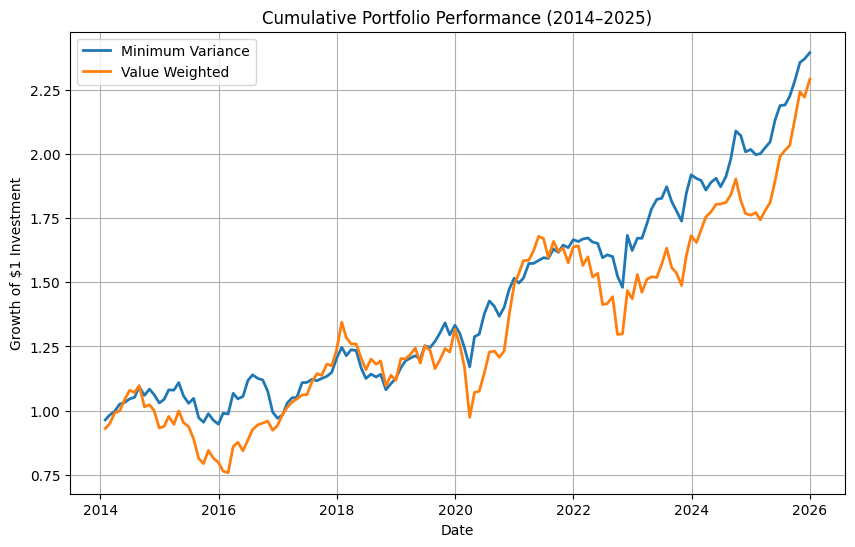

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(mv_cumulative, label="Minimum Variance", linewidth=2)
plt.plot(vw_cumulative, label="Value Weighted", linewidth=2)

plt.title("Cumulative Portfolio Performance (2014–2025)")
plt.ylabel("Growth of $1 Investment")
plt.xlabel("Date")

plt.legend()
plt.grid()

# Save figure before displaying it
plt.savefig(FIGURES_DIR / "cumulative_portfolio_performance.png", dpi=300, bbox_inches="tight")

plt.show()

## 11. Part I Summary


In this first part of the project, we constructed and evaluated a standard minimum variance portfolio using the Emerging Markets universe assigned to our group.

After cleaning the Datastream dataset, we computed monthly returns and defined a dynamic investment universe based on data availability and eligibility criteria. Using a rolling window of 120 monthly observations, we estimated the covariance matrix and constructed a long-only minimum variance portfolio, rebalanced annually.

The out-of-sample performance of this portfolio over the 2014–2025 period was then compared with that of the value-weighted benchmark portfolio. The empirical results show that the benchmark achieved a higher cumulative return over the sample period, while the minimum variance portfolio provides an alternative allocation rule based on variance minimization.

This first part establishes the empirical framework that will be used in the remainder of the project. In Part II, we extend this framework by incorporating carbon-related constraints into the portfolio construction process.


---

[GUIDE ÉQUIPE – À SUPPRIMER AVANT RENDU]

Cette section doit rester courte.

Objectifs :
- rappeler ce que l’on a fait dans la Part I
- mentionner brièvement le résultat principal
- introduire la Part II (contrainte carbone)

L’analyse détaillée et la discussion seront faites dans le rapport PDF.

---



# 12. Exports

In [64]:
# Save key outputs of Part I for reproducibility and later analysis

mv_returns_oos.to_csv(TABLES_DIR / "mv_returns_oos.csv")
vw_returns_oos.to_csv(TABLES_DIR / "vw_returns_oos.csv")
performance.to_csv(TABLES_DIR / "portfolio_performance_summary.csv")

print("Outputs successfully saved in:", TABLES_DIR)

Outputs successfully saved in: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/outputs/tables


In [65]:
# =========================================================
# Export results to the official Part I Excel template
# =========================================================

template_path = BASE_DIR / "Template for Part I-SAAM.xlsx"
output_template = OUTPUTS / "Part_I_results_filled.xlsx"

with pd.ExcelWriter(output_template, engine="openpyxl", mode="w") as writer:
    
    # Sheet 1 — Portfolio performance summary
    performance.to_excel(writer, sheet_name="Portfolio Performance", index=False)

    # Sheet 2 — Monthly returns
    returns_table = pd.DataFrame({
        "Date": mv_returns_oos.index,
        "Minimum Variance": mv_returns_oos.values,
        "Value Weighted": vw_returns_oos.values
    })
    
    returns_table.to_excel(writer, sheet_name="Monthly Returns", index=False)

print("Template successfully filled and saved to:")
print(output_template)

Template successfully filled and saved to:
/Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/outputs/Part_I_results_filled.xlsx


---

# Part II - Portfolio Allocation with Carbon Emission Reduction

**Group N | Region: Emerging Markets | Scope: CO2 Scope 1**

This part follows the structure of the project brief. It builds on the Part I minimum-variance and value-weighted portfolios, then studies how portfolio allocation changes once carbon objectives are introduced.

In [66]:
import sys
from pathlib import Path

# Path setup for the flattened SAAM-Project structure
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print('Project root:', PROJECT_DIR)


Project root: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability


## Preparatory Setup for Part II

Before implementing the carbon allocation exercises, we reload the project configuration and make the flattened project structure available to Python.

In [67]:
from src.config import (
    REGION, ROLLING_WINDOW_MONTHS, MIN_HISTORY_MONTHS,
    STALE_RETURN_THRESHOLD, LOW_PRICE_THRESHOLD,
    INITIAL_WEALTH, CARBON_REDUCTION_TARGET,
    NET_ZERO_REDUCTION, NET_ZERO_BASE_YEAR,
)
from src.paths import get_part2_paths, ensure_part2_directories

paths = get_part2_paths()
ensure_part2_directories(paths)

print(f'Region: {REGION}')
print(f'Carbon reduction target: {CARBON_REDUCTION_TARGET*100:.0f}%')
print(f'Net-zero annual reduction: {NET_ZERO_REDUCTION*100:.0f}%/yr')

Region: EM
Carbon reduction target: 50%
Net-zero annual reduction: 10%/yr


### Data and Carbon Inputs

We reuse the cleaned financial data from Part I and add the annual carbon emissions, revenues, and market capitalization variables needed to compute carbon intensity, WACI, and carbon footprint.

In [68]:
# Part I modules — imported directly from Part I/src/ (no 'src.' prefix)
# Project modules from the flattened src package
from src.loaders import load_raw_datasets
from src.cleaning import (
    prepare_price_data, prepare_market_caps_data, prepare_carbon_data,
    apply_low_price_filter, compute_returns, apply_delisting_returns,
)
# Part II carbon utilities
from src.carbon import prepare_revenue_data, prepare_annual_market_caps


static, prices_raw, market_caps_raw, carbon_scope1_raw = load_raw_datasets(paths['DATA_RAW'])
revenue_raw     = pd.read_excel(paths['DATA_RAW'] / 'DS_REV_Y_2025.xlsx')
annual_caps_raw = pd.read_excel(paths['DATA_RAW'] / 'DS_MV_T_USD_Y_2025.xlsx')

em_firms = static[static['Region'] == REGION].copy()
em_isins = em_firms['ISIN'].tolist()
print(f'EM universe: {len(em_isins)} ISINs in static file')

price_data       = apply_low_price_filter(prepare_price_data(prices_raw, em_isins), LOW_PRICE_THRESHOLD)
market_caps_data = prepare_market_caps_data(market_caps_raw, em_isins)
carbon_data      = prepare_carbon_data(carbon_scope1_raw, em_isins)
revenue_data     = prepare_revenue_data(revenue_raw, em_isins)
annual_caps_data = prepare_annual_market_caps(annual_caps_raw, em_isins)
returns_matrix   = apply_delisting_returns(price_data, compute_returns(price_data))

print(f'Returns matrix: {returns_matrix.shape}')
print(f'Carbon data: {carbon_data.shape}  |  Revenue: {revenue_data.shape}')

EM universe: 702 ISINs in static file
Returns matrix: (702, 314)
Carbon data: (702, 27)  |  Revenue: (702, 27)


### Investment Set

The investment universe remains the same dynamic universe defined in Part I: firms must belong to the assigned region, have enough return observations, and have carbon information available at the relevant allocation date.

In [69]:
# Make the common src/ folder available to this notebook

import sys
from pathlib import Path

# Start from the current working directory
PROJECT_ROOT = Path.cwd().resolve()

# Move upward until we find the project root containing src/
while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root containing src/")
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

# Add src/ to Python path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Using common src: {SRC_DIR}")

from universe import build_universe_by_year

rebalance_years = list(range(2014, 2026))

universe_by_year = build_universe_by_year(
    returns_matrix=returns_matrix,
    price_data=price_data,
    carbon_data=carbon_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    min_history_months=MIN_HISTORY_MONTHS,
    stale_return_threshold=STALE_RETURN_THRESHOLD,
)

for yr in rebalance_years:
    print(f'  {yr}: {len(universe_by_year[yr])} assets')

Project root: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project
Using common src: /Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/src
  2014: 254 assets
  2015: 278 assets
  2016: 309 assets
  2017: 345 assets
  2018: 389 assets
  2019: 424 assets
  2020: 472 assets
  2021: 511 assets
  2022: 546 assets
  2023: 573 assets
  2024: 584 assets
  2025: 568 assets


### Baseline Portfolios from Part I

The minimum-variance portfolio $P_{oos}^{mv}$ and the value-weighted benchmark $P_{oos}^{vw}$ are recomputed here so that the carbon strategies can be compared against the same baseline portfolios.

In [70]:
from optimization import compute_mv_weights_by_year
from backtest import run_mv_backtest
from benchmark import run_vw_backtest

mv_weights_by_year = compute_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

_, mv_returns_oos = run_mv_backtest(returns_matrix, mv_weights_by_year, rebalance_years)
_, vw_returns_oos = run_vw_backtest(returns_matrix, market_caps_data, universe_by_year, rebalance_years)

print('Part I backtests complete.')

[optimization] 2014: computing minimum-variance weights for 254 assets...
[optimization] 2014: done.
[optimization] 2015: computing minimum-variance weights for 278 assets...
[optimization] 2015: done.
[optimization] 2016: computing minimum-variance weights for 309 assets...
[optimization] 2016: done.
[optimization] 2017: computing minimum-variance weights for 345 assets...
[optimization] 2017: done.
[optimization] 2018: computing minimum-variance weights for 389 assets...
[optimization] 2018: done.
[optimization] 2019: computing minimum-variance weights for 424 assets...
[optimization] 2019: done.
[optimization] 2020: computing minimum-variance weights for 472 assets...
[optimization] 2020: done.
[optimization] 2021: computing minimum-variance weights for 511 assets...
[optimization] 2021: done.
[optimization] 2022: computing minimum-variance weights for 546 assets...
[optimization] 2022: done.
[optimization] 2023: computing minimum-variance weights for 573 assets...
[optimization] 20

## 3. Allocation with a 50% Reduction in Carbon Emissions

This section adds a climate objective to the portfolio construction. The target is to reduce portfolio carbon exposure by 50% relative to the relevant benchmark carbon footprint.

### 3.1 Carbon Emissions

Carbon intensity is computed as annual CO2 emissions divided by revenues, expressed in tonnes of CO2 per million USD of revenue:

$$CI_{i,Y} = \frac{E_{i,Y}}{Rev_{i,Y} / 1000}$$

In [71]:
from src.carbon import (
    compute_carbon_intensity,
    compute_cf_per_unit,
    compute_portfolio_cf,
    compute_portfolio_waci,
    compute_vw_cf,
    get_top_carbon_emitters,
)
from src.backtest_part2 import (
    run_portfolio_backtest,
    compute_carbon_metrics_timeseries,
    compute_vw_carbon_metrics_timeseries,
)

carbon_intensity = compute_carbon_intensity(carbon_data, revenue_data)
print(f'Carbon intensity matrix: {carbon_intensity.shape}')
carbon_intensity.describe().T[['mean', 'min', 'max']]

Carbon intensity matrix: (702, 27)


,mean,min,max
1999-12-31,NaN,NaN,NaN
2000-12-31,NaN,NaN,NaN
2001-12-31,NaN,NaN,NaN
2002-12-31,NaN,NaN,NaN
2003-12-31,1795.6389,1795.6389,1795.6389
...,...,...,...
2021-12-31,695.7185,0.0031,14482.8675
2022-12-31,567.1284,0.0000,17512.4995
2023-12-31,509.2356,0.0000,20373.0496
2024-12-31,541.6335,0.0000,19839.3111


#### Weighted-Average Carbon Intensity and Carbon Footprint

For each portfolio, we compute both WACI and carbon footprint. WACI measures exposure to firms' carbon intensity, while carbon footprint measures the annual emissions attributed to the investor per million USD invested.

$$WACI^{(p)}_Y = \sum_i \alpha_{i,Y}CI_{i,Y}$$

$$CF^{(p)}_Y = \sum_i \alpha_{i,Y} \frac{E_{i,Y}}{Cap_{i,Y}} \qquad CF^{(vw)}_Y = \frac{\sum_i E_{i,Y}}{\sum_i Cap_{i,Y}}$$

In [72]:
mv_waci_series, mv_cf_series = compute_carbon_metrics_timeseries(
    weights_by_year=mv_weights_by_year,
    universe_by_year=universe_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    carbon_intensity=carbon_intensity,
    rebalance_years=rebalance_years,
)

vw_waci_series, vw_cf_series = compute_vw_carbon_metrics_timeseries(
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    carbon_intensity=carbon_intensity,
    rebalance_years=rebalance_years,
)

from src.reporting_part2 import build_carbon_metrics_table
build_carbon_metrics_table(
    {'MV': mv_waci_series, 'VW': vw_waci_series},
    {'MV': mv_cf_series,   'VW': vw_cf_series},
)

,Avg WACI (tCO2/M$ rev),Avg CF (tCO2/M$ inv),Min CF,Max CF
Portfolio,,,,
MV,409.1159,283.3353,20.7125,634.8333
VW,429.2308,547.0110,403.4775,670.5661


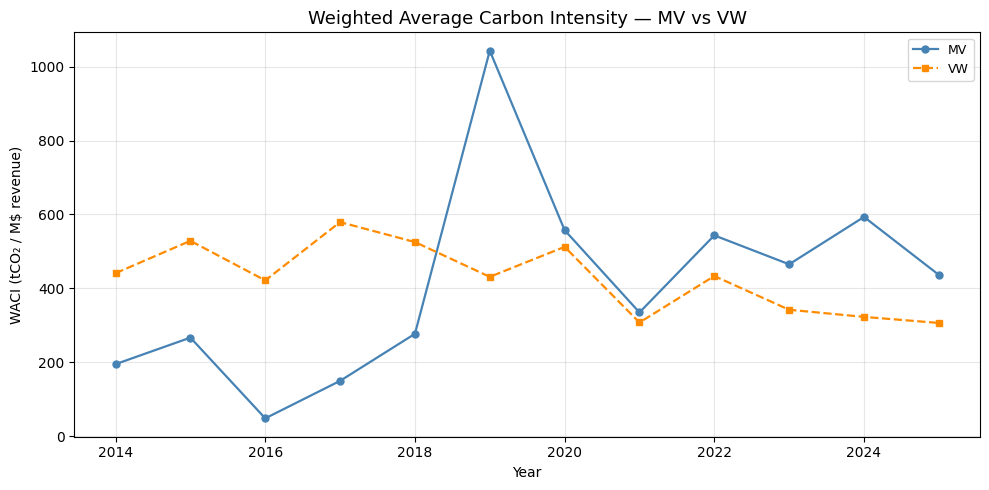

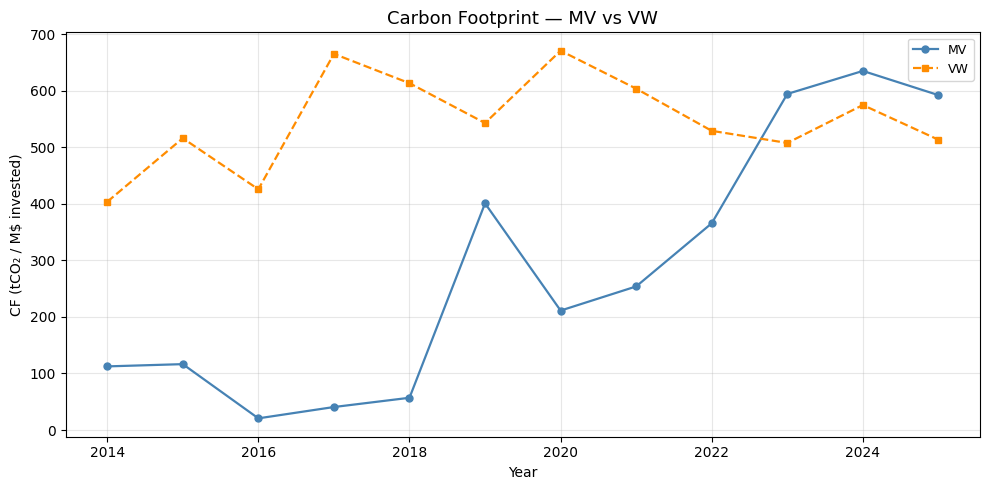

PosixPath('/Users/lionel/Documents/HEC/Master hec /Semestre 2/Sustainability/SAAM-Project/outputs/figures/cf_mv_vw.png')

In [73]:
from src.reporting_part2 import plot_carbon_metrics

plot_carbon_metrics(
    {'MV': mv_waci_series, 'VW': vw_waci_series},
    ylabel='WACI (tCO\u2082 / M$ revenue)',
    title='Weighted Average Carbon Intensity \u2014 MV vs VW',
    figures_dir=paths['FIGURES_DIR'],
    filename='waci_mv_vw.png',
    show_plot=True,
)

plot_carbon_metrics(
    {'MV': mv_cf_series, 'VW': vw_cf_series},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint \u2014 MV vs VW',
    figures_dir=paths['FIGURES_DIR'],
    filename='cf_mv_vw.png',
    show_plot=True,
)

In [74]:
# Top-10 carbon-intensive firms (last rebalance year)
last_year     = rebalance_years[-1]
last_end      = pd.Timestamp(f'{last_year - 1}-12-31')
universe_last = universe_by_year[last_year]

cf_pu_last = compute_cf_per_unit(carbon_data, annual_caps_data, universe_last, last_end)

top10 = get_top_carbon_emitters(
    weights=mv_weights_by_year[last_year],
    cf_per_unit=cf_pu_last,
    static_df=static,
    n=10,
)
print('Top 10 firms driving carbon intensity (MV portfolio, last rebalance):')
display(top10)

Top 10 firms driving carbon intensity (MV portfolio, last rebalance):


,ISIN,Weighted_CF_Contribution,Name,Weight,CF_per_unit
0,PK0053401011,172.0282,FAUJI FERTILIZER COMPANY,0.0398,4324.4409
1,PEP702101002,143.0754,ENGIE ENERGIA PERU,0.0475,3012.3566
2,CNE1000002S8,134.5707,COSCO SHIP.EN.TRSP. 'H',0.0377,3568.1110
3,PHY751061151,68.7926,SAN MIGUEL,0.0134,5146.8262
4,PHY5764J1483,46.9779,MANILA ELECTRIC,0.0317,1479.9359
5,CNE000000SJ9,8.7280,SHAI.ZHENHUA HEAVY IND. 'B',0.0179,488.0296
6,TH0450010Y08,4.7487,THAI UNION GROUP,0.0424,112.0606
7,KR7004370003,3.6749,NONGSHIM,0.0711,51.6802
8,PHY0005M1090,1.9857,ABOITIZ POWER,0.0165,120.6668
9,MYL6033OO004,1.3671,PETRONAS GAS,0.0017,816.2869


### 3.2 Long-Only Portfolio with a Carbon Footprint Objective

We construct a long-only minimum-variance portfolio whose carbon footprint is at least 50% below the carbon footprint of the unconstrained minimum-variance portfolio.

$$\min_{\alpha} \;\alpha' \Sigma \alpha$$

subject to:

$$CF^{(p)}_Y \le 0.5 \times CF^{(P_{oos}^{mv})}_Y, \qquad \alpha'\mathbf{1}=1, \qquad \alpha_i \ge 0$$

We denote this portfolio $P_{oos}^{mv}(0.5)$.

In [ ]:
from src.optimization_part2 import compute_carbon_mv_weights_by_year

mv_cf_by_year = mv_cf_series.to_dict()

carbon_mv_weights = compute_carbon_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    mv_cf_by_year=mv_cf_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    carbon_reduction_target=CARBON_REDUCTION_TARGET,
)

_, carbon_mv_returns = run_portfolio_backtest(returns_matrix, carbon_mv_weights, rebalance_years)
print('Section 3.2 done.')

[carbon-MV] 2014: 254 assets ...
  [carbon-MV] 2014: done.
[carbon-MV] 2015: 278 assets ...
  [carbon-MV] 2015: done.
[carbon-MV] 2016: 309 assets ...
  [carbon-MV] 2016: done.
[carbon-MV] 2017: 345 assets ...
  [carbon-MV] 2017: done.
[carbon-MV] 2018: 389 assets ...
  [carbon-MV] 2018: done.
[carbon-MV] 2019: 424 assets ...
  [carbon-MV] 2019: done.
[carbon-MV] 2020: 472 assets ...


In [ ]:
from src.reporting_part2 import (
    build_performance_table, compute_cumulative_returns, plot_cumulative_performance
)

cmv_waci, cmv_cf = compute_carbon_metrics_timeseries(
    carbon_mv_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_32 = {'MV': mv_returns_oos, 'MV (0.5)': carbon_mv_returns}
print('\nSection 3.2 \u2014 Performance:')
display(build_performance_table(returns_32))

plot_cumulative_performance(
    compute_cumulative_returns(returns_32), paths['FIGURES_DIR'],
    filename='cumulative_section32.png',
    title='Cumulative Returns: MV vs MV(0.5)', show_plot=True,
)
plot_carbon_metrics(
    {'MV': mv_cf_series, 'MV (0.5)': cmv_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: MV vs MV(0.5)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section32.png', show_plot=True,
)

### 3.3 Tracking Error Minimization

We now take the point of view of a passive investor: the objective is to remain as close as possible to the value-weighted benchmark while reducing the carbon footprint by 50%.

$$\min_{\alpha} \; TE = \sqrt{(\alpha - \alpha^{vw})' \Sigma (\alpha - \alpha^{vw})}$$

subject to:

$$CF^{(p)}_Y \le 0.5 \times CF^{(P_{oos}^{vw})}_Y, \qquad \alpha'\mathbf{1}=1, \qquad \alpha_i \ge 0$$

We denote this portfolio $P_{oos}^{vw}(0.5)$.

In [ ]:
from src.optimization_part2 import compute_te_min_weights_by_year

vw_cf_by_year   = vw_cf_series.to_dict()
cf_target_50_vw = {yr: CARBON_REDUCTION_TARGET * vw_cf_by_year[yr] for yr in rebalance_years}

te_50_weights = compute_te_min_weights_by_year(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    cf_target_by_year=cf_target_50_vw,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

_, te_50_returns = run_portfolio_backtest(returns_matrix, te_50_weights, rebalance_years)
print('Section 3.3 done.')

In [ ]:
te50_waci, te50_cf = compute_carbon_metrics_timeseries(
    te_50_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_33 = {'VW': vw_returns_oos, 'VW (0.5)': te_50_returns}
print('\nSection 3.3 \u2014 Performance:')
display(build_performance_table(returns_33))

plot_cumulative_performance(
    compute_cumulative_returns(returns_33), paths['FIGURES_DIR'],
    filename='cumulative_section33.png',
    title='Cumulative Returns: VW vs VW(0.5)', show_plot=True,
)
plot_carbon_metrics(
    {'VW': vw_cf_series, 'VW (0.5)': te50_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: VW vs VW(0.5)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section33.png', show_plot=True,
)

### 3.4 Comparison of Portfolios

We compare the financial performance and carbon outcomes of the baseline portfolios and the 50% carbon-reduction portfolios. The key trade-off is between tracking or variance efficiency and the reduction in carbon footprint.

In [ ]:
# Baseline CF^(vw) at end of Y0=2013, used as reference for all net-zero targets
base_year_date = pd.Timestamp(f'{NET_ZERO_BASE_YEAR}-12-31')      # 2013-12-31 ✓
base_universe  = universe_by_year[BACKTEST_START_YEAR]             # universe at start of 2014
vw_cf_base     = compute_vw_cf(carbon_data, annual_caps_data, base_universe, base_year_date)

print(f'VW CF baseline (end {NET_ZERO_BASE_YEAR}): {vw_cf_base:.4f} tCO₂/M$')

# CF target for each rebalance year: (1-θ)^(Y-Y0) * CF_Y0
cf_target_nz = {
    yr: (1 - NET_ZERO_REDUCTION) ** (yr - NET_ZERO_BASE_YEAR) * vw_cf_base
    for yr in rebalance_years
}
print('\nNet-zero CF targets:')
for yr, val in cf_target_nz.items():
    print(f'  {yr}: {val:.4f}')

In [ ]:
# Cumulative returns: all 4 portfolios together
all_4_returns = {
    'MV': mv_returns_oos,
    'MV (0.5)': carbon_mv_returns,
    'VW': vw_returns_oos,
    'VW (0.5)': te_50_returns,
}

# Cumulative returns: all 4 portfolios together
plot_cumulative_performance(
    compute_cumulative_returns(all_4_returns),
    figures_dir=paths['FIGURES_DIR'],
    filename='cumulative_section34.png',
    title='Cumulative Returns: MV, MV(0.5), VW, VW(0.5)',
    show_plot=True,
)


# CF over time: all 4 portfolios
plot_carbon_metrics(
    {'MV': mv_cf_series, 'MV (0.5)': cmv_cf, 'VW': vw_cf_series, 'VW (0.5)': te50_cf},
    ylabel='CF (tCO₂ / M$ invested)',
    title='Carbon Footprint: All Portfolios (Section 3.4)',
    figures_dir=paths['FIGURES_DIR'],
    filename='cf_section34.png',
    show_plot=True,
)

## 4. Portfolio Allocation with a Net Zero Objective

The final climate strategy introduces a dynamic carbon reduction path rather than a single 50% constraint.

### 4.1 Net Zero Portfolio

The portfolio carbon footprint is reduced by $\theta = 10\%$ per year from the base year $Y_0 = 2013$:

$$CF^{(p)}_Y \le (1-\theta)^{Y-Y_0+1} \times CF^{(P_{oos}^{vw})}_{Y_0}$$

We denote this portfolio $P_{oos}^{vw}(NZ)$.

In [ ]:
base_year_date = pd.Timestamp(f'{NET_ZERO_BASE_YEAR - 1}-12-31')
base_universe  = universe_by_year[NET_ZERO_BASE_YEAR + 1]
vw_cf_base     = compute_vw_cf(carbon_data, annual_caps_data, base_universe, base_year_date)

print(f'VW CF baseline (end {NET_ZERO_BASE_YEAR}): {vw_cf_base:.4f} tCO\u2082/M$')

cf_target_nz = {
    yr: (1 - NET_ZERO_REDUCTION) ** (yr - NET_ZERO_BASE_YEAR + 1) * vw_cf_base
    for yr in rebalance_years
}
print('\nNet-zero CF targets:')
for yr, val in cf_target_nz.items():
    print(f'  {yr}: {val:.4f}')

In [ ]:
nz_weights = compute_te_min_weights_by_year(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    cf_target_by_year=cf_target_nz,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

_, nz_returns = run_portfolio_backtest(returns_matrix, nz_weights, rebalance_years)
print('Section 4.1 done.')

### 4.2 Comparison of Portfolios

We compare the cumulative performance of $P_{oos}^{vw}$, $P_{oos}^{vw}(0.5)$, and $P_{oos}^{vw}(NZ)$, and discuss the possible financial cost of constructing a net-zero portfolio.

In [ ]:
nz_waci, nz_cf = compute_carbon_metrics_timeseries(
    nz_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_sec4 = {'VW': vw_returns_oos, 'VW (0.5)': te_50_returns, 'VW (NZ)': nz_returns}
print('Section 4.2 \u2014 Performance:')
display(build_performance_table(returns_sec4))

plot_cumulative_performance(
    compute_cumulative_returns(returns_sec4), paths['FIGURES_DIR'],
    filename='cumulative_section4.png',
    title='Cumulative Returns: VW, VW(0.5) and VW(NZ)', show_plot=True,
)
plot_carbon_metrics(
    {'VW': vw_cf_series, 'VW (0.5)': te50_cf, 'VW (NZ)': nz_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: VW, VW(0.5) and VW(NZ)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section4.png', show_plot=True,
)

## Part II Summary and Export

This final block gathers the performance and carbon metrics for all portfolios and exports the tables required to reproduce the report outputs.

In [ ]:
from src.reporting_part2 import build_carbon_metrics_table, export_part2_outputs

all_returns = {
    'MV':       mv_returns_oos,
    'MV (0.5)': carbon_mv_returns,
    'VW':       vw_returns_oos,
    'VW (0.5)': te_50_returns,
    'VW (NZ)':  nz_returns,
}
waci_all = {
    'MV': mv_waci_series, 'MV (0.5)': cmv_waci,
    'VW': vw_waci_series, 'VW (0.5)': te50_waci, 'VW (NZ)': nz_waci,
}
cf_all = {
    'MV': mv_cf_series, 'MV (0.5)': cmv_cf,
    'VW': vw_cf_series, 'VW (0.5)': te50_cf, 'VW (NZ)': nz_cf,
}

perf_summary   = build_performance_table(all_returns)
carbon_summary = build_carbon_metrics_table(waci_all, cf_all)

print('=== Performance Summary ===')
display(perf_summary)
print('\n=== Carbon Metrics Summary ===')
display(carbon_summary)

In [ ]:
exported = export_part2_outputs(all_returns, waci_all, cf_all, paths['TABLES_DIR'])
perf_summary.to_csv(paths['TABLES_DIR'] / 'performance_summary_part2.csv')
carbon_summary.to_csv(paths['TABLES_DIR'] / 'carbon_metrics_summary_part2.csv')

print('All outputs saved.')
for k, v in exported.items():
    print(f'  {k}: {v.name}')